In [1]:
import uproot
# from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
import numpy as np
import vector
import matplotlib.pyplot as plt
import os
from tqdm.auto import tqdm

vector.register_awkward() 

In [2]:
file_name = "/depot/cms/users/das214/HHtobbtautau/NanoFullwithGen.root"
f = uproot.open(file_name)

In [3]:
PAD_VAL = -99999
class PDGID:
    d = 1
    u = 2
    s = 3
    c = 4
    b = 5
    t = 6
    e = 11
    ve = 12
    mu = 13
    vmu = 14
    tau = 15
    vtau = 16
    gluon = 21
    gamma = 22
    Z = 23
    W = 24
    H = 25
    bhadrons = (511, 521, 523)
    pions = (111, 211)

In [4]:
def build_GenPart(events):
    gen_part_branches = [key for key in events.keys() if key.startswith("GenPart_")]
    gen_part_dict = {}
    for branch_name in tqdm(gen_part_branches):
        short_name = branch_name.replace("GenPart_", "")
        gen_part_dict[short_name] = events[branch_name].array()
        
    GenPart = ak.zip(
        gen_part_dict,
        with_name="Momentum4D"
    )
    
    
    return GenPart

In [5]:
def get_Gen_HHtobbtautau(GenPart):
    is_last_copy = (GenPart.statusFlags & (1 << 13)) != 0
    is_higgs_bosons =(GenPart.pdgId == PDGID.H) & is_last_copy


    num_higgs = ak.sum(is_higgs_bosons, axis=1)

    print("Number of Higgs per event:")
    print(num_higgs)
    GenH_ = GenPart[is_higgs_bosons]
    display(GenH_)
    has_two_higgs = ak.num(GenH_) == 2
    print(has_two_higgs)
    print(GenH_)
    
    GenPart_indices = ak.local_index(GenPart.pt, axis=1) # index of each GenPart
    higgs_indices = GenPart_indices[is_higgs_bosons] # indices of higgs

    # Mother_Id is the idx of the mother for each particle
    # We can create a boolean array to check if the mother is a higgs

    # GenPart.genPartIdxMother[:, :, np.newaxis]: (n_events, n_particles, 1)
    # higgs_idx: (n_events, 1, n_higgs)

    is_child_of_higgs = ak.any(GenPart.genPartIdxMother[:, :, np.newaxis] == higgs_indices[:, np.newaxis, :], axis=2) # (n_events, n_particles)
    higgs_children = GenPart[is_child_of_higgs]

    is_b_quark = abs(higgs_children.pdgId) == PDGID.b
    is_tau = abs(higgs_children.pdgId) == PDGID.tau
    
    num_b_from_H = ak.sum(is_b_quark, axis=1)
    num_tau_from_H = ak.sum(is_tau, axis=1)

    print("Number of b from Higgs per event:")
    print(num_b_from_H)
    print("Number of tau from Higgs per event:")
    print(num_tau_from_H)
    
    is_bbtautau_event = (num_b_from_H == 2) & (num_tau_from_H == 2)
    GenH = GenH_[is_bbtautau_event]
    Genb = higgs_children[is_b_quark][is_bbtautau_event]
    Gentau = higgs_children[is_tau][is_bbtautau_event]
    
    return GenH, Genb, Gentau
    

In [6]:
events = f["Events"]

GenPart = build_GenPart(events)
GenH, Genb, Gentau = get_Gen_HHtobbtautau(GenPart)
weights = np.ones(len(GenH)) # placeholder for weights (CHANGE THIS)

  0%|          | 0/9 [00:00<?, ?it/s]

Number of Higgs per event:
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


<MomentumArray4D [[{genPartIdxMother: 23, ... iso: 0}]] type='387218 * var * Mom...'>

[True, True, True, True, True, True, True, ... True, True, True, True, True, True]
[[{genPartIdxMother: 23, statusFlags: 10497, pdgId: 25, ... pt: 160, iso: 0}]]
Number of b from Higgs per event:
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Number of tau from Higgs per event:
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ... 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [7]:
# --- Verification ---
print(f"Total events: {len(GenPart)}")
print(f"Selected HH->bbtautau events: {len(GenH)}")

print("\n--- PDG IDs of b's from selected events ---")
print(Genb.pdgId)

print("\n--- PDG IDs of taus from selected events ---")
print(Gentau.pdgId)


Total events: 387218
Selected HH->bbtautau events: 387218

--- PDG IDs of b's from selected events ---
[[5, -5], [5, -5], [5, -5], [5, -5], [5, ... -5], [5, -5], [5, -5], [5, -5], [5, -5]]

--- PDG IDs of taus from selected events ---
[[15, -15], [15, -15], [15, -15], [15, ... -15], [15, -15], [15, -15], [15, -15]]


In [11]:
acc_cond = {
    'eta_tau': 2.5, 'pt_tau': 20,
    'eta_b': 2.5, 'pt_b': 40,
}

acc_mask_tau = ak.all(
    (Gentau.pt > acc_cond['pt_tau']) &
    (abs(Gentau.eta) < acc_cond['eta_tau']),
    axis=1
)

acc_mask_b = ak.all(
    (Genb.pt > acc_cond['pt_b']) &
    (abs(Genb.eta) < acc_cond['eta_b']),
    axis=1
)

acc_mask_total = acc_mask_tau & acc_mask_b


GenH_acc = GenH[acc_mask_total]
Genb_acc = Genb[acc_mask_total]
Gentau_acc = Gentau[acc_mask_total]
weights_acc = weights[acc_mask_total]


print(f"Events passing acceptance: {len(GenH_acc)}")

Events passing acceptance: 164711


In [12]:
def delta_r(obj1, obj2):
    """Delta_R with stable, wrapped Delta_phi."""
    phi1, eta1 = obj1.phi, obj1.eta
    phi2, eta2 = obj2.phi, obj2.eta
    d_phi = np.mod(phi1 - phi2 + np.pi, 2*np.pi) - np.pi # making \phi \in [-pi, +pi]
    d_eta = eta1 - eta2
    d_R = np.hypot(d_eta, d_phi)
    return d_R

In [13]:
def gen_categorization_ak(gen_b, gen_tau, deltaR_threshold_boosted, deltaR_threshold_resolved):
    deltaR_bb = delta_r(gen_b[:, 0], gen_b[:, 1])
    deltaR_tau = delta_r(gen_tau[:, 0], gen_tau[:, 1])

    gen_cat_bb_boosted = deltaR_bb < deltaR_threshold_boosted
    gen_cat_tau_boosted = deltaR_tau < deltaR_threshold_boosted
    gen_cat_bb_resolved = deltaR_bb > deltaR_threshold_resolved
    gen_cat_tau_resolved = deltaR_tau > deltaR_threshold_resolved

    return gen_cat_bb_boosted, gen_cat_bb_resolved, gen_cat_tau_boosted, gen_cat_tau_resolved

gen_cat_bb_boosted, gen_cat_bb_resolved, gen_cat_tau_boosted, gen_cat_tau_resolved = gen_categorization_ak(Genb_acc, Gentau_acc, 0.8, 0.4)

total_weight = weights_acc.sum()
print(f'[GEN] boosted bb & boosted ττ: {weights_acc[gen_cat_bb_boosted & gen_cat_tau_boosted].sum() / total_weight:.4f}')
print(f'[GEN] boosted bb & resolved ττ: {weights_acc[gen_cat_bb_boosted & gen_cat_tau_resolved].sum() / total_weight:.4f}')
print(f'[GEN] resolved bb & boosted ττ: {weights_acc[gen_cat_bb_resolved & gen_cat_tau_boosted].sum() / total_weight:.4f}')
print(f'[GEN] resolved bb & resolved ττ: {weights_acc[gen_cat_bb_resolved & gen_cat_tau_resolved].sum() / total_weight:.4f}')

[GEN] boosted bb & boosted ττ: 0.0156
[GEN] boosted bb & resolved ττ: 0.0366
[GEN] resolved bb & boosted ττ: 0.0301
[GEN] resolved bb & resolved ττ: 0.9989


In [14]:
def build_collection(events, name):
    branches = [key for key in tqdm(events.keys()) if key.startswith(name + "_")]
    coll_dict = {
        branch.replace(name + "_", ""): events[branch].array() for branch in branches
    }
    return ak.zip(coll_dict)

ScoutingFatJets = build_collection(events, "ScoutingFatPFJetRecluster")
ScoutingJets = build_collection(events, "ScoutingPFJetRecluster")

ScoutingFatJets_acc = ScoutingFatJets[acc_mask_total]
ScoutingJets_acc = ScoutingJets[acc_mask_total]

  0%|          | 0/1491 [00:00<?, ?it/s]

  0%|          | 0/1491 [00:00<?, ?it/s]

In [15]:
def match_jets_to_obj(jets, obj, dr_max):
    """
    Returns
    -------
    match_mask : (N, J, O) boolean
        True if jet j in event n matches object o.
    """

    # jets_* = (N, J) 
    # obj_*  = (N, O)
    # jests_*[..., None] = (N, J, 1) 
    # obj_*[:,  None, :]  = (N, 1, O)
    # compute Delta R between each jet and each object (per event)
    
    dR = delta_r(jets[..., None], obj[:,  None, :])
    cond = (dR < dr_max) #& (jets_pt[..., None] > pt_min) #  (N, J, O)
    return cond #  (N, J, O) # Check this implementation

In [16]:
b_ak8_mask = match_jets_to_obj(ScoutingFatJets_acc, Genb_acc, dr_max=0.8)
b_ak4_mask = match_jets_to_obj(ScoutingJets_acc, Genb_acc, dr_max=0.4)

tau_ak8_mask = match_jets_to_obj(ScoutingFatJets_acc, Gentau_acc, dr_max=0.8)
tau_ak4_mask = match_jets_to_obj(ScoutingJets_acc, Gentau_acc, dr_max=0.4)

In [17]:
both_b_in_one_ak8 = ak.all(b_ak8_mask, axis=2)
reco_cat_bb_boosted = ak.any(both_b_in_one_ak8, axis=1)

both_tau_in_one_ak8 = ak.all(tau_ak8_mask, axis=2)
reco_cat_tau_boosted = ak.any(both_tau_in_one_ak8, axis=1)


is_jet_matched_to_any_b = ak.any(b_ak4_mask, axis=2)
num_jets_matched_to_bs = ak.sum(is_jet_matched_to_any_b, axis=1)
reco_cat_bb_resolved = (num_jets_matched_to_bs >= 2)

is_jet_matched_to_any_tau = ak.any(tau_ak4_mask, axis=2)
num_jets_matched_to_taus = ak.sum(is_jet_matched_to_any_tau, axis=1)
reco_cat_tau_resolved = (num_jets_matched_to_taus >= 2)

print(f"[RECO] (Boosted): Events with a boosted bb candidate: {ak.sum(reco_cat_bb_boosted)}")
print(f"[RECO] (Boosted): Events with a boosted ττ candidate: {ak.sum(reco_cat_tau_boosted)}")
print(f"[RECO] (Resolved): Events with a resolved bb candidate: {ak.sum(reco_cat_bb_resolved)}")
print(f"[RECO] (Resolved): Events with a resolved ττ candidate: {ak.sum(reco_cat_tau_resolved)}")

[RECO] (Boosted): Events with a boosted bb candidate: 9155
[RECO] (Boosted): Events with a boosted ττ candidate: 3737
[RECO] (Resolved): Events with a resolved bb candidate: 148695
[RECO] (Resolved): Events with a resolved ττ candidate: 116693


In [18]:
fully_boosted_pass = reco_cat_bb_boosted & reco_cat_tau_boosted # Both bb and ττ are boosted
fully_resolved_pass = reco_cat_bb_resolved & reco_cat_tau_resolved # Both bb and ττ are resolved

semi_resolved_bb_pass = reco_cat_bb_resolved & reco_cat_tau_boosted # bb is resolved and ττ is boosted
semi_resolved_tautau_pass = reco_cat_bb_boosted & reco_cat_tau_resolved # bb is boosted and ττ is resolved

print(f"[RECO] Booosted: {ak.sum(fully_boosted_pass)}")
print(f"[RECO] Semi-Resolved(bb): {ak.sum(semi_resolved_bb_pass)}")
print(f"[RECO] Semi-Resolved(ττ): {ak.sum(semi_resolved_tautau_pass)}")
print(f"[RECO] Resolved: {ak.sum(fully_resolved_pass)}")

[RECO] Booosted: 2315
[RECO] Semi-Resolved(bb): 3447
[RECO] Semi-Resolved(ττ): 7218
[RECO] Resolved: 105694


In [30]:
def efficiency_vs(var, masks, bins, weights=None):
    reco_mask, truth_mask = masks
    mask_numerator = reco_mask #& truth_mask
    mask_denominator =  np.ones(len(var), dtype=bool) # reco_mask

    if weights is None:
        weights = np.ones_like(var)

    numerator, _ = np.histogram(var[mask_numerator], bins=bins, 
                                weights=weights[mask_numerator]
                                ) 

    denominator, _ = np.histogram(var[mask_denominator], bins=bins, 
                                  weights=weights[mask_denominator]
                                  ) 

    denom_w2, _ = np.histogram(
        var[mask_denominator],
        bins=bins,
        weights=weights[mask_denominator] ** 2
    )

    # plain efficiency
    eff = np.divide(
        numerator, denominator,
        out=np.zeros_like(numerator, dtype=float),
        where=denominator > 0
    )

    # N_eff and 1 Sigma band
    neff = np.divide(
        denominator ** 2, denom_w2,
        out=np.zeros_like(denominator, dtype=float),
        where=denom_w2 > 0
    )
    err = np.sqrt(eff * (1.0 - eff) / (1e-6 + neff), where=neff >= 0)
    err_up = np.minimum(eff + err, 1.0)
    err_down = np.maximum(eff - err, 0.0)
    eff.clip(min=0.0, max=1.0, out=eff)

    # return eff, err, denominator, numerator
    return eff, err_up, err_down, denominator, numerator


def yields_vs(var, reco_mask, bins, weights=None):
    if weights is None:
        weights = np.ones_like(var)
    y, _ = np.histogram(var[reco_mask], bins=bins,
                        weights=weights[reco_mask])
    w2, _ = np.histogram(var[reco_mask], bins=bins,
                         weights=weights[reco_mask] ** 2)
    err = np.sqrt(w2)
    return y, err

In [20]:
import mplhep as hep        # CMS/ATLAS/LHCb approved styles  <--:contentReference[oaicite:0]{index=0}

hep.style.use("CMS")

plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "legend.frameon": True,
    "legend.framealpha": 1.0,        
    "legend.facecolor": 'white',      
    "legend.edgecolor": 'black',      
    "legend.fancybox": True,         
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "lines.linewidth": 2,
    "axes.linewidth": 1.2,

    "figure.dpi": 100,          
    "savefig.dpi": 300,   

    "figure.figsize": (10, 7),   

})



def cms_sim_prelim(ax,
                   lumi_fb=110.0,
                   energy=13.6,
                   loc=0):
    """CMS Simulation Preliminary, Run-3 lumi & √s."""
    hep.cms.label(ax=ax,
                  data=False,               # gives "Simulation"
                  label="Preliminary",
                  lumi=lumi_fb,
                  com=energy,
                  loc=loc,
                  fontsize=20
                  )


In [25]:
GenPart_acc = GenPart[acc_mask_total]
hbb_mother_idx = Genb_acc[:, 0].genPartIdxMother
htt_mother_idx = Gentau_acc[:, 0].genPartIdxMother


event_indices = ak.Array(np.arange(len(GenPart_acc)))

hbbpt = GenPart_acc[event_indices, hbb_mother_idx].pt
httpt = GenPart_acc[event_indices, htt_mother_idx].pt

# Your mhh calculation is already correct
mhh = (GenH_acc[:, 0] + GenH_acc[:, 1]).mass


plot_vars = [
    (mhh, "mhh", r"$m_{HH}$ [GeV]", np.linspace(0, 1800, 40)),
    (hbbpt, "hbbpt", r"Hbb $p_{T}$ [GeV]", np.linspace(0, 1200, 20)),
    (httpt, "httpt", r"H$\tau\tau$ $p_{T}$ [GeV]", np.linspace(0, 1200, 20)),
]

In [28]:
semi_resolved_bb_exc_pass = semi_resolved_bb_pass & ~fully_boosted_pass
semi_resolved_tautau_exc_pass = semi_resolved_tautau_pass & ~fully_boosted_pass

categories = [
    {
        'key'  : 'full_boosted',
        'label': r'Boosted $bb$ + Boosted $\tau\tau$',
        'color': '#1f77b4',
        'mask' : fully_boosted_pass,
    },
    {
        'key'  : 'bbBoost_tauRes_all',
        'label': r'Boosted $bb$ + Resolved $\tau\tau$',
        'color': '#fd8d3c',
        'mask' : semi_resolved_tautau_pass,
    },
    {
        'key'  : 'bbBoost_tauRes_exc',
        'label': r'Boosted $bb$ + Resolved $\tau\tau$ (excl.)',
        'color': '#c96100',
        'mask' : semi_resolved_tautau_exc_pass,
    },
    {
        'key'  : 'bbRes_tauBoost_all',
        'label': r'Resolved $bb$ + Boosted $\tau\tau$',
        'color': '#74c476',
        'mask' : semi_resolved_bb_pass,
    },
    {
        'key'  : 'bbRes_tauBoost_exc',
        'label': r'Resolved $bb$ + Boosted $\tau\tau$ (excl.)',
        'color': '#31a354',
        'mask' : semi_resolved_bb_exc_pass,
    },
    {
        'key' : 'full_resolved',
        'label': r'Resolved $bb$ + Resolved $\tau\tau$',
        'color': '#000000',
        'mask' : fully_resolved_pass
    }
]

for cat in categories:
    total_weight = weights_acc[cat['mask']].sum()
    print(f"{cat['label']}: {total_weight:.3f}")



Boosted $bb$ + Boosted $\tau\tau$: 2315.000
Boosted $bb$ + Resolved $\tau\tau$: 7218.000
Boosted $bb$ + Resolved $\tau\tau$ (excl.): 5128.000
Resolved $bb$ + Boosted $\tau\tau$: 3447.000
Resolved $bb$ + Boosted $\tau\tau$ (excl.): 1325.000
Resolved $bb$ + Resolved $\tau\tau$: 105694.000


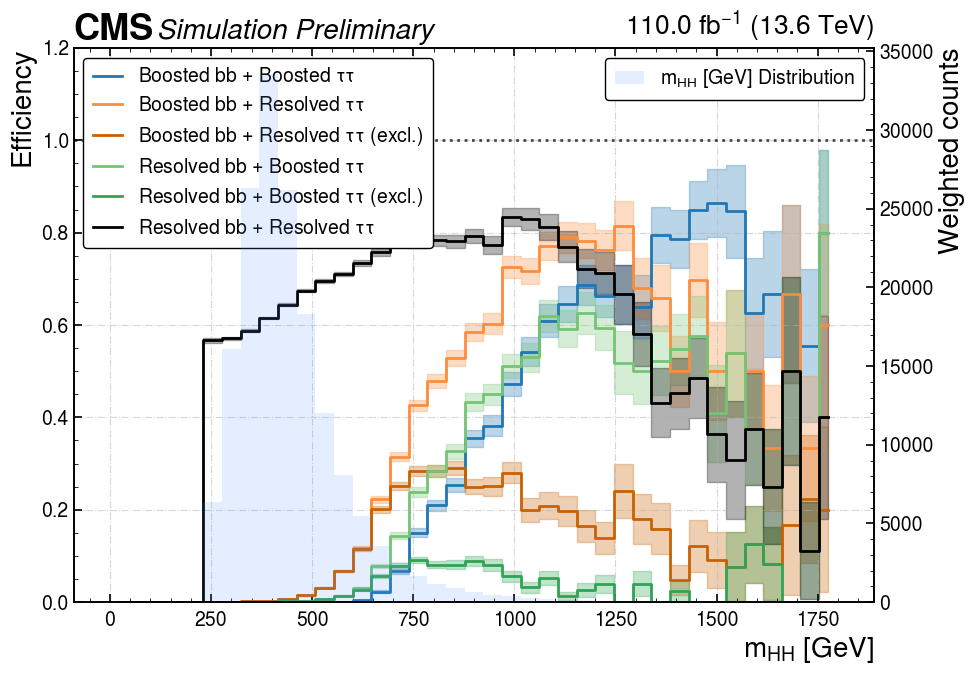

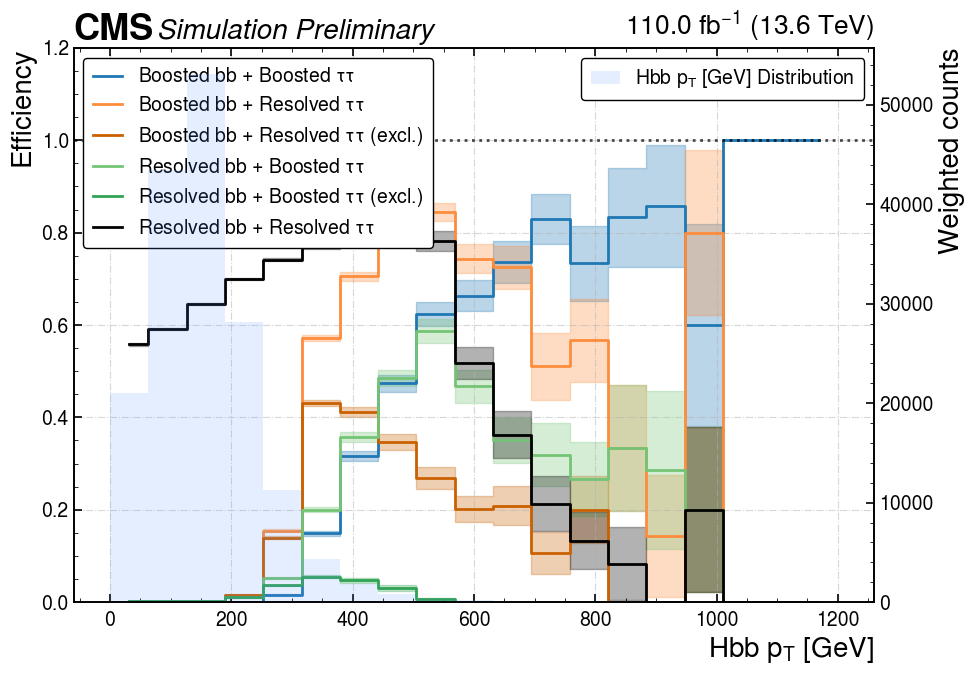

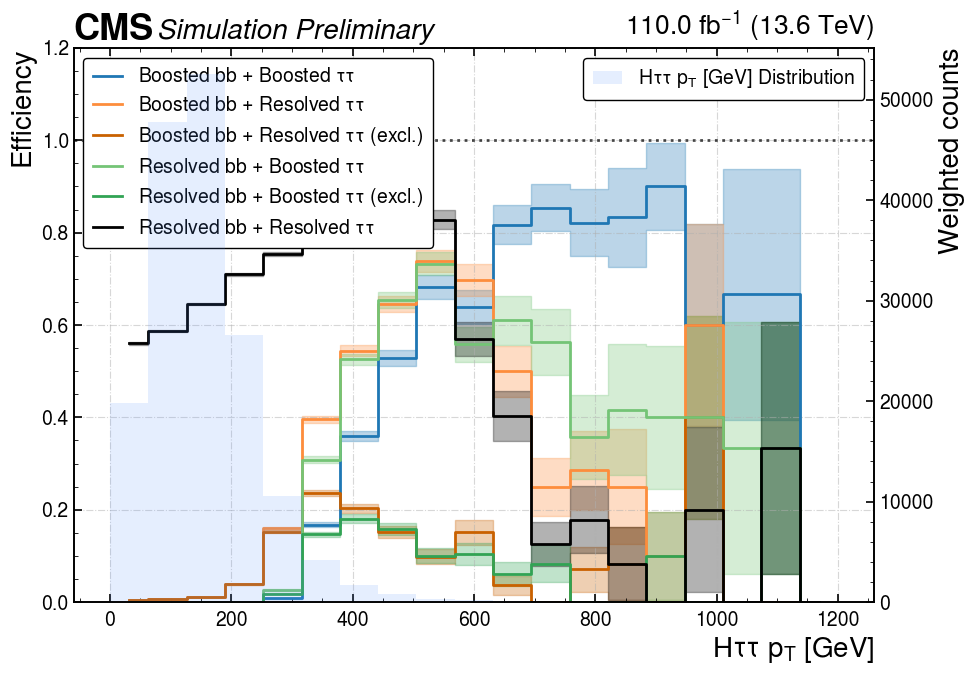

In [29]:
for kinvar, kinname, kinlabel, bins in plot_vars:
    bc = 0.5 * (bins[1:] + bins[:-1])
    width = np.diff(bins)

    fig, ax = plt.subplots(figsize=(10, 7))
    cms_sim_prelim(ax)  

    for cat in categories:
        eff, err_up, err_down, tot, _ = efficiency_vs(
            kinvar,
            (cat['mask'], cat['mask']),
            bins,
            weights_acc
        )

        ax.step(bc, eff, where='mid', lw=2,
                label=cat['label'], color=cat['color'])
        ax.fill_between(bc, err_down, err_up, step='mid',
                        alpha=0.3, color=cat['color'])

    ax.set(xlabel=kinlabel, ylabel='Efficiency', ylim=(0, 1.2))
    ax.axhline(y=1, linestyle=':', color='black', alpha=0.7, linewidth=2)
    ax.grid(ls='-.', alpha=.5)

    ax2 = ax.twinx()
    ax2.bar(bc, tot, width=width, alpha=0.15,
            label=kinlabel + ' Distribution')
    ax2.set_ylabel('Weighted counts')

    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


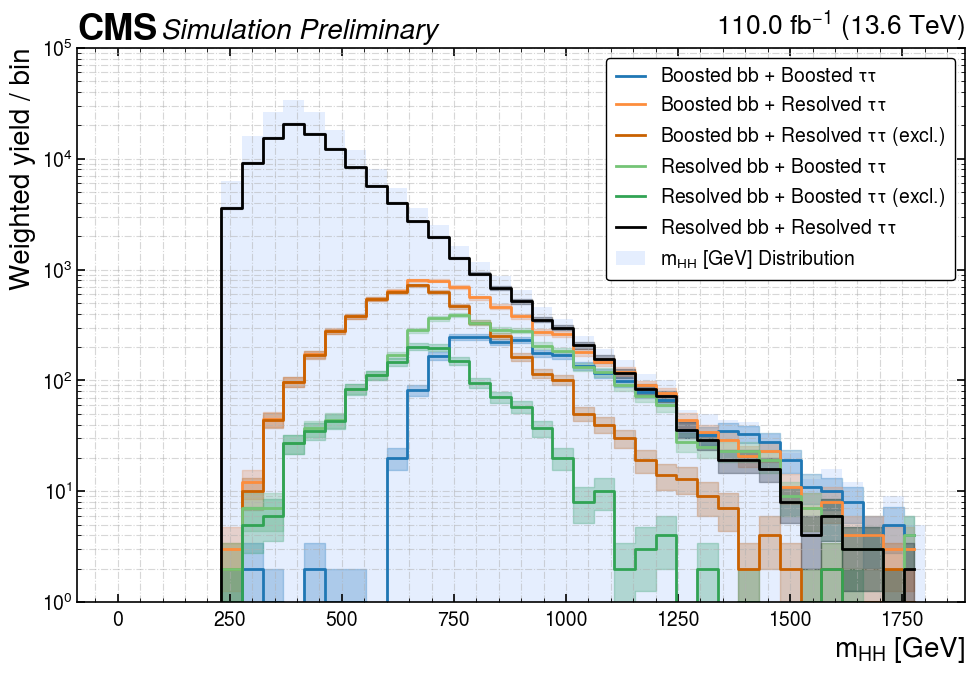

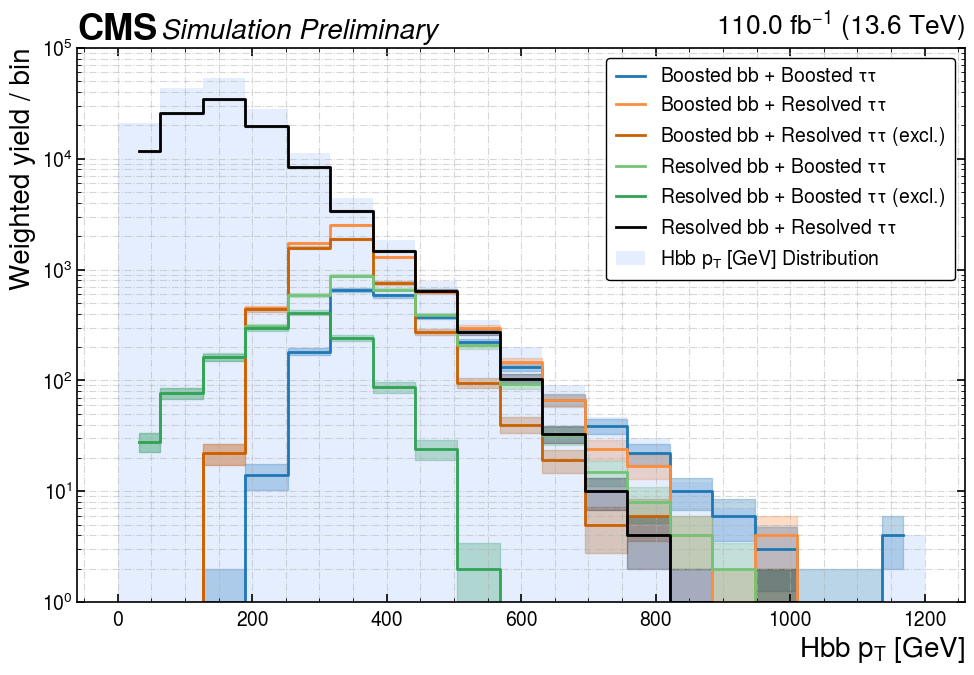

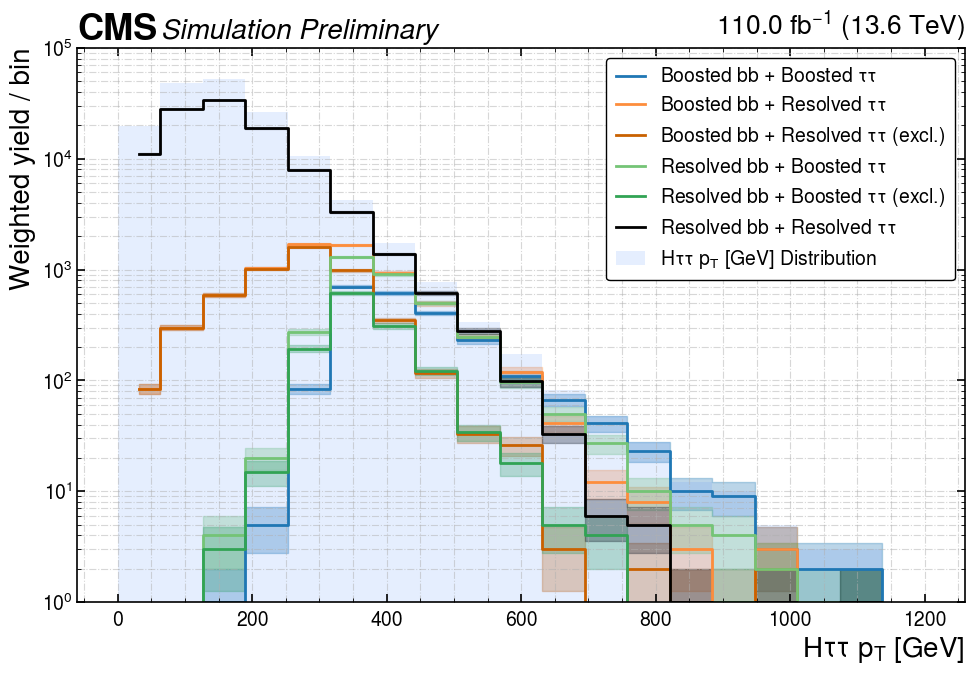

In [36]:


CLIP_MIN = 1e-12  # unify clipping across all plots
CLIP_plot_MIN = 1e0
CLIP_plot_MAX = 1e5

for kinvar, kinname, kinlabel, bins in plot_vars:
    bc = 0.5 * (bins[1:] + bins[:-1])
    width = np.diff(bins)

    # Total background distribution (selected)
    tot, _ = np.histogram(kinvar, bins=bins,
                          weights=weights_acc)
    tot = np.clip(tot, CLIP_MIN, None)

    fig, ax = plt.subplots(figsize=(10, 7))
    cms_sim_prelim(ax)

    ax.set_yscale('log')
    ax.set_ylim(ymin=CLIP_plot_MIN, ymax = CLIP_plot_MAX)

    # Step plots with error bands for each category
    for cat in categories:
        y, err = yields_vs(kinvar, cat['mask'], bins,
                           weights_acc)
        y = np.clip(y, CLIP_MIN, None)
        err = np.minimum(err, y)

        ax.step(bc, y, where='mid', lw=2,
                label=cat['label'], color=cat['color'])
        ax.fill_between(bc, y - err, y + err,
                        step='mid', alpha=0.3,
                        color=cat['color'])

    ax.bar(bc, tot, width=width, alpha=0.15,
           label=kinlabel + ' Distribution')

    ax.set(xlabel=kinlabel,
           ylabel='Weighted yield / bin')
    ax.grid(ls='-.', alpha=0.5, which='both')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



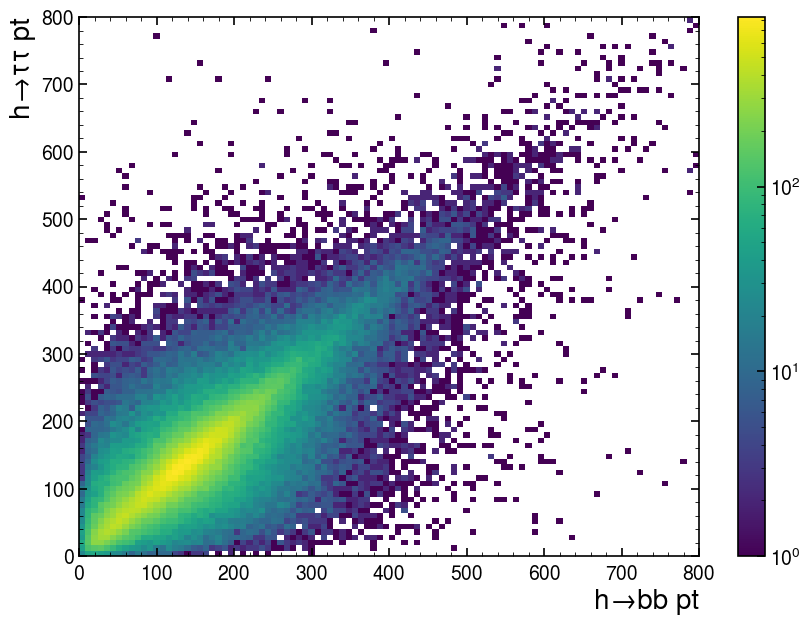

In [41]:
from matplotlib.colors import LogNorm 

plt.hist2d(ak.to_numpy(hbbpt), 
           ak.to_numpy(httpt), 
           bins=100, norm=LogNorm(), 
           range=[[0, 800], [0, 800]],)

plt.colorbar()
plt.xlabel("h→bb pt")
plt.ylabel("h→ττ pt")
plt.show()

In [42]:
from scipy.stats import beta

def efficiency_2d(x: np.ndarray,
                  y: np.ndarray,
                  pass_mask: np.ndarray,
                  bins_x: np.ndarray,
                  bins_y: np.ndarray,
                  weights: np.ndarray | None = None,
                  cl: float = 0.6827):

    w = np.ones_like(x, dtype=float) if weights is None else weights

    tot, _, _ = np.histogram2d(x, y, bins=[bins_x, bins_y],
                               weights=w)

    num, _, _ = np.histogram2d(x, y, bins=[bins_x, bins_y],
                               weights=w * pass_mask)

    eff = np.divide(num, tot, out=np.zeros_like(num),
                    where=tot > 0)

    # Clopper-Pearson
    a = beta.ppf((1 - cl) / 2, num, tot - num + 1)
    b = beta.ppf(1 - (1 - cl) / 2, num + 1, tot - num)
    err_low = eff - np.where(tot > 0, a, 0)
    err_up  = np.where(tot > 0, b, 0) - eff

    return eff, err_low, err_up, num, tot


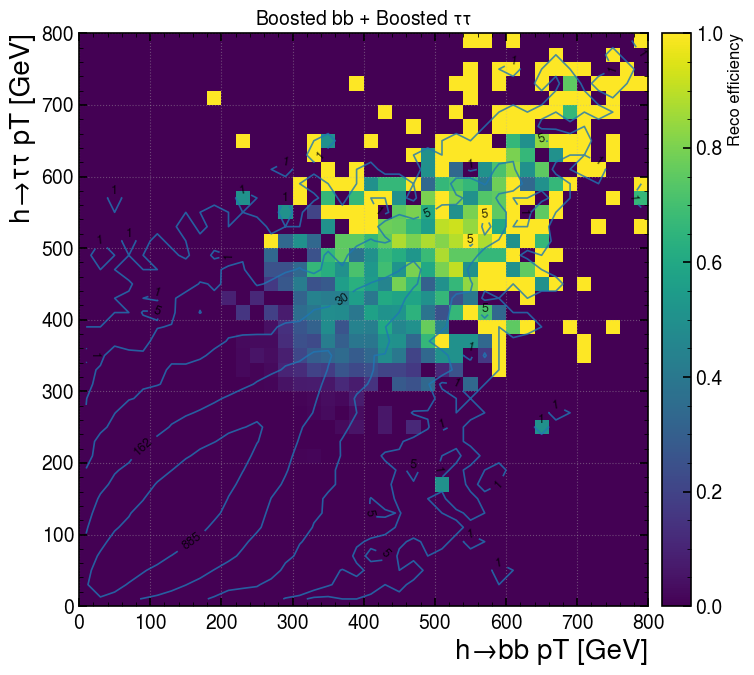

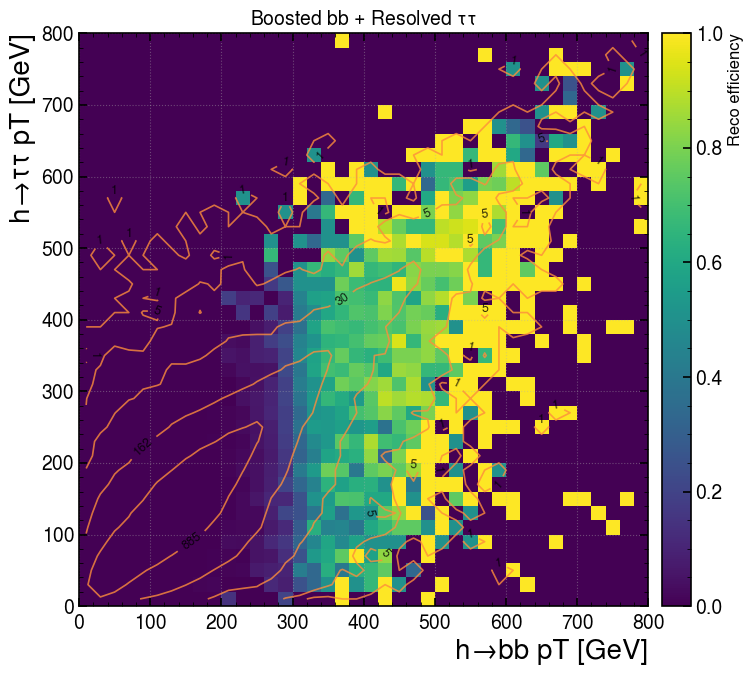

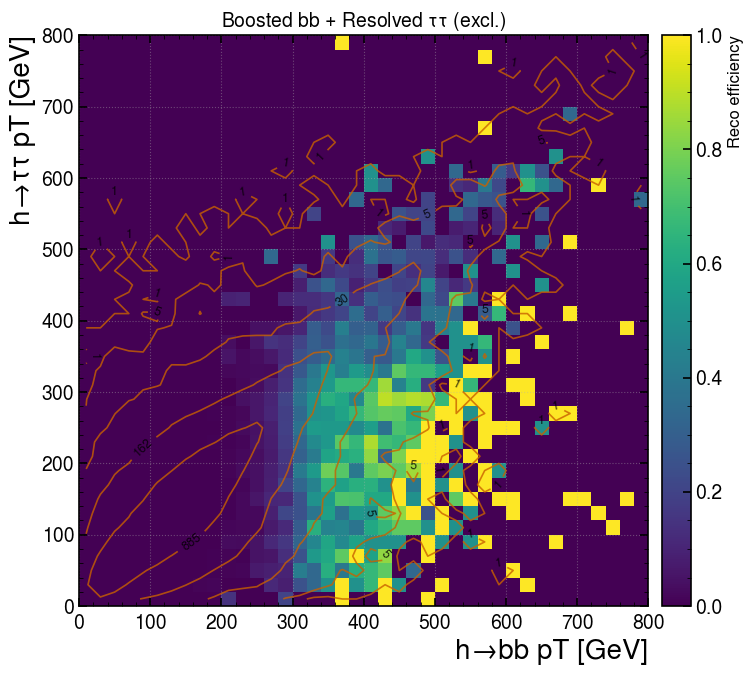

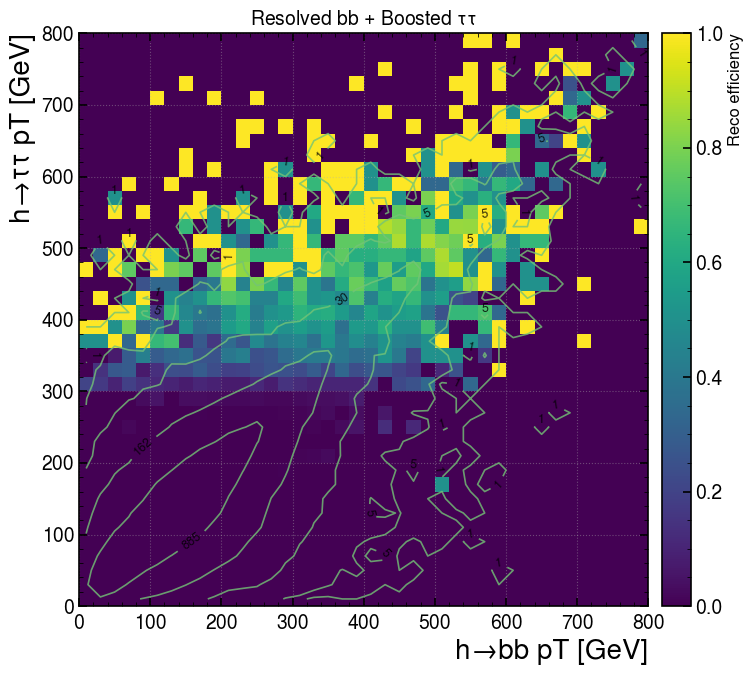

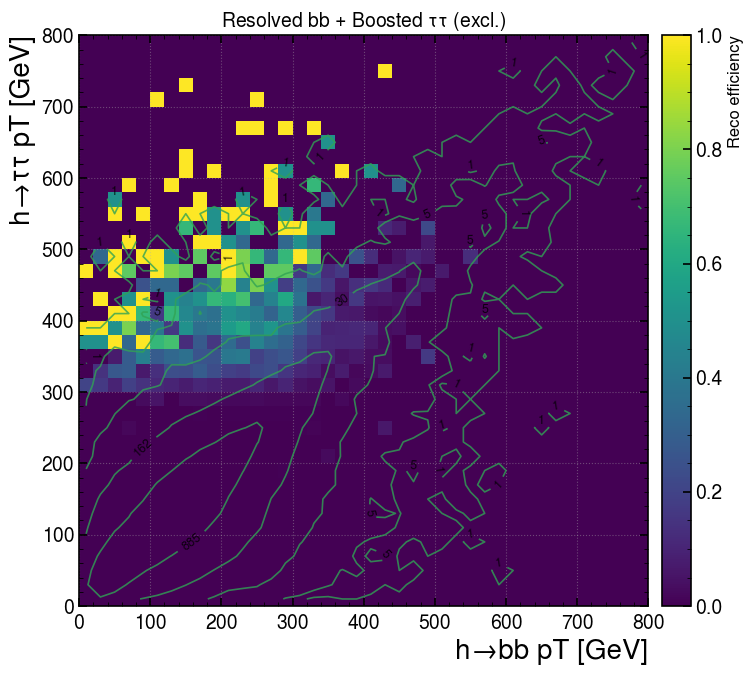

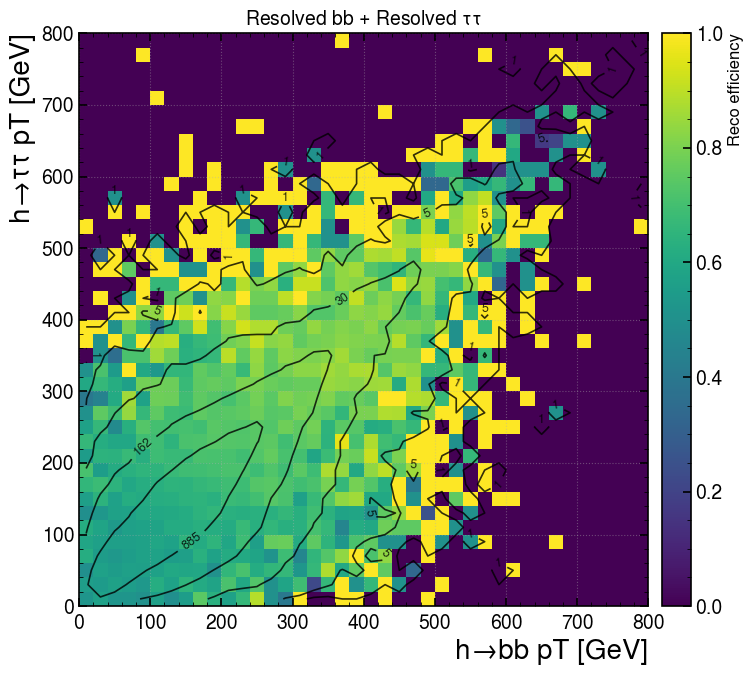

In [ ]:
xbins = np.linspace(0, 800, 41)     # h→bb pT
ybins = np.linspace(0, 800, 41)     # h→ττ pT

cat_colour = {c['key']: c['color'] for c in categories}

for cat in categories:
    eff, err_lo, err_hi, num, tot = efficiency_2d(
        hbbpt, httpt, cat['mask'], xbins, ybins, weights_acc
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    # Efficiency heatmap
    mesh = ax.pcolormesh(
        xbins, ybins, eff.T,
        vmin=0, vmax=1, cmap='viridis',
        shading='auto'
    )
    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label('Reco efficiency', fontsize=12)

    # Smoothed bin centers for contours
    xmid = 0.5 * (xbins[:-1] + xbins[1:])
    ymid = 0.5 * (ybins[:-1] + ybins[1:])
    X, Y = np.meshgrid(xmid, ymid)

    # Contour over total events
    lev = np.geomspace(tot[tot > 0].min(), tot.max(), 6)
    cont = ax.contour(
        X, Y, tot.T,
        levels=lev,
        colors=[cat_colour[cat['key']]],
        linewidths=1.2,
        alpha=0.8
    )

    # Add text labels to contours
    ax.clabel(
        cont, fmt='%.0f', fontsize=9,
        inline=True, colors='black'
    )

    ax.set_xlabel('h→bb pT [GeV]')
    ax.set_ylabel('h→ττ pT [GeV]')
    ax.set_title(f'{cat["label"]}', fontsize=14)
    ax.grid(ls=':', alpha=0.4)
    plt.tight_layout()
    plt.show()
